In [19]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import joblib
import pickle
from scipy.stats import randint, uniform

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.supabase_handler import fetch_csv_from_supabase

# Load dữ liệu

In [20]:
df = fetch_csv_from_supabase("Raw_Features")

# Convert price from VND to billion VND
df['price_billion_vnd'] = df['price_vnd'] / 1e9

print(f"✓ Loaded {len(df)} records, {len(df.columns)} columns")
print(f"Price range: {df['price_billion_vnd'].min():.2f} – {df['price_billion_vnd'].max():.2f} billion VND")

# Save a snapshot of the raw data
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
df.to_csv(data_dir / 'raw_data.csv', index=False)
print("✓ Saved snapshot: data/raw_data.csv")

df.head(10)

📖 Fetching data from Supabase table: Raw_Features
✓ Fetched 8643 rows from Raw_Features

✓ Loaded 8643 records, 46 columns
Price range: 0.00 – 2100.00 billion VND
✓ Saved snapshot: data/raw_data.csv


,link,title,post_day,street,old_address,locality,region,listing_id,direction,listing_type,...,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,nearest_bus_stop_km,bus_stop_count_1km,nearest_metro_km,metro_count_5km,description,price_billion_vnd
0,https://alonhadat.com.vn/ban-nha-rieng-hem-xe-...,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,2026-05-23,đường lê quang định,"Đường Lê Quang Định, Phường 14, Quận Bình Thạn...",phường bình thạnh,hồ chí minh,18269430,unknown,can_ban,...,0.127429,61,3.067850,0,0.108269,47,2.080087,7,None,8.90
1,https://alonhadat.com.vn/sieu-vi-tri-toa-nha-h...,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,2026-05-27,đường lê thánh tôn,"Đường Lê Thánh Tôn, Phường Bến Nghé, Quận 1, H...",phường sài gòn,hồ chí minh,17891053,unknown,can_ban,...,0.331273,97,0.690744,15,0.089534,68,0.352320,7,None,110.00
2,https://alonhadat.com.vn/ban-gap-nha-4-tang-ng...,"BÁN GẤP NHÀ 4 TẦNG NGANG KHỦNG 4,8M – TRẦN QUA...",2026-06-30,đường trần quang diệu,"Đường Trần Quang Diệu, Phường 14, Quận 3, Hồ C...",phường nhiêu lộc,hồ chí minh,18843030,unknown,can_ban,...,0.293004,108,0.833065,16,0.144080,55,2.531594,4,None,7.99
3,https://alonhadat.com.vn/4x11-nha-co-2-lau-moi...,"4x11, nhà có 2 lầu mới đường số 3, giáp Thạch LAM",2026-06-30,đường số 3,"Đường Số 3, Phường Bình Hưng Hòa A, Quận Bình ...",phường bình hưng hòa,hồ chí minh,18614772,unknown,can_ban,...,1.674035,14,1.509740,1,0.521155,15,NaN,0,None,4.35
4,https://alonhadat.com.vn/ban-biet-thu-khu-comp...,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,2026-05-27,đường nguyễn trọng tuyển,"Đường Nguyễn Trọng Tuyển, Phường 10, Quận Phú ...",phường phú nhuận,hồ chí minh,16693368,unknown,can_ban,...,0.256364,53,1.945490,6,0.155312,47,3.900285,4,None,45.00
5,https://alonhadat.com.vn/thanh-ly-can-nha-cap-...,Thanh lý căn nhà 1 trệt 1 lầu TP.HCM bán trả nợ,2026-06-10,đường bình hưng,"Đường Bình Hưng, Xã Bình Hưng, Huyện Bình Chán...",xã bình hưng,hồ chí minh,18767045,unknown,can_ban,...,1.922488,5,1.961150,3,0.154980,18,NaN,0,None,1.05
6,https://alonhadat.com.vn/4x14-nha-duc-4-tam-kh...,"4x14, nhà đúc 4 tấm, khu Lê văn Quới vào, đườn...",2026-06-30,đường số 14,"Đường Số 14, Phường Bình Hưng Hòa A, Quận Bình...",phường bình hưng hòa,hồ chí minh,18835058,unknown,can_ban,...,0.555815,26,2.498830,1,0.400331,11,NaN,0,None,5.38
7,https://alonhadat.com.vn/-hem-xe-hoi-7m-4-tang...,🏡 HÀNG HIẾM BÌNH THẠNH - CHỈ NHÚ 7 TỶ SỞ HỮU H...,2026-06-30,đường bình lợi,"Đường Bình Lợi, Phường 13, Quận Bình Thạnh, Hồ...",phường bình lợi trung,hồ chí minh,18826870,unknown,can_ban,...,0.726789,44,1.764600,7,0.160326,39,3.402818,5,None,7.30
8,https://alonhadat.com.vn/nha-moi-chu-gui-ban-l...,"NHÀ MỚI CHỦ GỬI BÁN LẠI GIÁ 1TỶ950TR SỔ RIÊNG,...",2026-07-01,đường dương đình cúc,"Đường Dương Đình Cúc, Xã Tân Kiên, Huyện Bình ...",xã tân nhựt,hồ chí minh,18854782,unknown,can_ban,...,1.840131,3,NaN,0,0.008888,29,NaN,0,None,1.95
9,https://alonhadat.com.vn/ban-nha-mat-tien-duon...,Bán nhà mặt tiền đường số 2 khu The Vista An P...,2026-07-01,đường số 2,"Đường Số 2, Phường An Khánh, Thành phố Thủ Đức...",phường an khánh,hồ chí minh,18854229,unknown,can_ban,...,0.559203,26,0.968627,6,0.217555,12,1.038473,8,None,45.00


### 1.2 Features & target

In [21]:
# Numeric features (geospatial + property)
NUMERIC_COLS = [
    'nearest_school_km', 'school_count_3km',
    'nearest_hospital_km', 'hospital_count_5km',
    'nearest_marketplace_km', 'marketplace_count_3km',
    'nearest_supermarket_km', 'supermarket_count_3km',
    'nearest_mall_km', 'mall_count_3km',
    'nearest_bus_stop_km', 'bus_stop_count_1km',
    'nearest_metro_km', 'metro_count_5km',
    'area_m2', 'distance_to_center_km',
    'num_floors', 'num_bedrooms', 'road_width_m', 'width_m', 'length_m',
    'locality_population_density','locality_square', 'lat', 'lon',
]

# Binary features (True/False → 0/1)
BIN_COLS = [
    'dining_room_bin', 'kitchen_bin', 'terrace_bin',
    'car_parking_bin', 'owner_listing_bin'
]

# Text features → one-hot encode
CAT_COLS = ['property_type', 'legal_status', 'direction']

# Dropped: locality, region, locality_square (location identifiers),
# listing_type (single value), link/title/street/addresses (free text), lat/lon
TARGET_COL = 'price_billion_vnd'

print(f"{len(NUMERIC_COLS)} numeric + {len(BIN_COLS)} binary + {len(CAT_COLS)} categorical, target = {TARGET_COL}")

25 numeric + 5 binary + 3 categorical, target = price_billion_vnd


### 1.3 Khám phá dữ liệu training

Thống kê mô tả và tỉ lệ thiếu dữ liệu của các cột dùng để train.

In [22]:
# Descriptive statistics of numeric features + target
df[NUMERIC_COLS + [TARGET_COL]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
nearest_school_km,8640.0,0.32,0.31,0.00,0.14,0.24,0.42,4.91
school_count_3km,8643.0,102.42,59.34,0.00,56.00,93.00,151.00,226.00
nearest_hospital_km,8619.0,1.02,0.87,0.00,0.38,0.76,1.42,5.00
hospital_count_5km,8643.0,42.63,30.72,0.00,12.00,39.00,76.00,92.00
nearest_marketplace_km,8622.0,0.67,0.55,0.00,0.34,0.51,0.86,4.49
marketplace_count_3km,8643.0,20.30,15.77,0.00,8.00,16.00,32.00,61.00
nearest_supermarket_km,8513.0,0.67,0.62,0.00,0.25,0.49,0.88,4.93
supermarket_count_3km,8643.0,39.23,33.10,0.00,11.00,28.00,61.00,117.00
nearest_mall_km,8152.0,1.71,1.09,0.03,0.80,1.53,2.27,5.07
mall_count_3km,8643.0,5.99,5.90,0.00,1.00,4.00,9.00,21.00


In [23]:
# Missing values per training column
cols = NUMERIC_COLS + BIN_COLS + CAT_COLS + [TARGET_COL]
missing = df[cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
missing_table[missing_table['missing'] > 0].sort_values('missing', ascending=False)

,missing,missing_%
nearest_metro_km,3695,42.8
length_m,1101,12.7
width_m,810,9.4
nearest_mall_km,491,5.7
num_floors,185,2.1
nearest_supermarket_km,130,1.5
num_bedrooms,125,1.4
nearest_hospital_km,24,0.3
road_width_m,21,0.2
nearest_marketplace_km,21,0.2


In [24]:
# Binary & categorical features overview
for col in BIN_COLS:
    counts = df[col].value_counts()
    print(f"{col:22s} True: {counts.get(True, 0):>5} | False: {counts.get(False, 0):>5}")

for col in CAT_COLS:
    print(f"\n{col}:")
    print(df[col].fillna('(missing)').value_counts().to_string())

dining_room_bin        True:  3773 | False:  4870
kitchen_bin            True:  3826 | False:  4817
terrace_bin            True:  2993 | False:  5650
car_parking_bin        True:  3111 | False:  5532
owner_listing_bin      True:     3 | False:  8640

property_type:
property_type
nha_mat_tien     4386
nha_trong_hem    4257

legal_status:
legal_status
so_hong_so_do     5871
unknown           2429
giay_to_hop_le     343

direction:
direction
unknown     7965
dong_nam     200
tay_bac       92
tay_nam       87
dong_bac      68
dong          68
tay           57
bac           56
nam           50


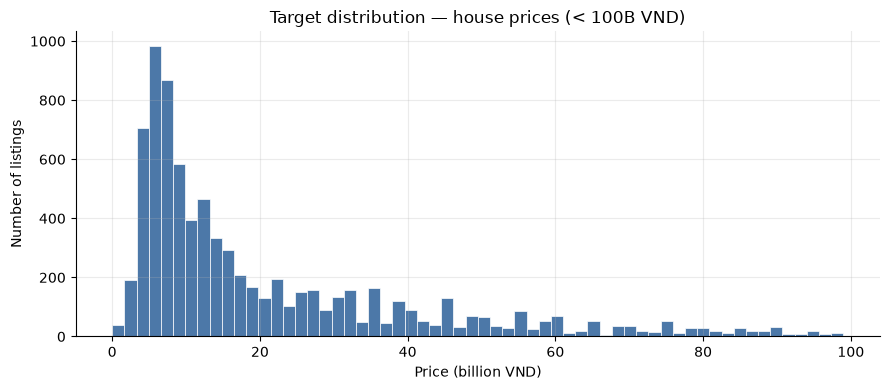

Median price: 13.50 billion VND


In [25]:
# Distribution of the target (house prices)
prices = df[TARGET_COL].dropna()
prices_plot = prices[prices < 100]  # same outlier cutoff as training

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prices_plot, bins=60, color='#4C78A8', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Price (billion VND)')
ax.set_ylabel('Number of listings')
ax.set_title('Target distribution — house prices (< 100B VND)')
ax.grid(True, alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median price: {prices.median():.2f} billion VND")

### 1.4 Chuẩn bị dữ liệu

Quy tắc xử lý missing:

- `nearest_*` → điền **max** của cột (thiếu nghĩa là không có tiện ích gần), kèm cờ `*_missing` để model phân biệt "xa thật" và "không có dữ liệu"
- `length_m` / `width_m` → thiếu 1 trong 2 thì suy ra từ `area_m2 / cạnh còn lại`; thiếu cả 2 thì điền median (kèm cờ `*_missing`)
- `num_*`, `road_width_m` → điền median
- Thiếu `locality_population_density` → **drop dòng**
- Bin → 0/1, cột chữ → one-hot

Feature bổ sung:

- 12 flag từ khóa trích từ `title` (hẻm xe hơi, mặt tiền, biệt thự, thang máy...)
- `locality_price_median`: giá trung vị theo phường, tính **chỉ trên train set** (thêm ở bước 1.5 để tránh leakage)

Lọc outlier (giá + dữ liệu vật lý vô lý do lỗi crawl):

- Giá: 0.1 < giá ≤ 100 tỷ
- `area_m2` 10–1000 m², `num_floors` ≤ 15, `num_bedrooms` ≤ 20, `width_m` ≤ 50m, `length_m` ≤ 100m, `road_width_m` ≤ 60m

In [26]:
# Columns that get a missing-indicator flag (computed BEFORE imputation,
# so the model can tell "far away" apart from "no data, filled with max")
MISS_FLAG_COLS = ['nearest_metro_km', 'nearest_mall_km', 'nearest_supermarket_km', 'width_m', 'length_m']

# Title keyword flags — simple substring matching, each becomes a 0/1 feature
TITLE_FLAGS = {
    'title_hem_xe_hoi': r'hẻm xe hơi|hxh',
    'title_mat_tien':   r'mặt tiền|mat tien',
    'title_biet_thu':   r'biệt thự|villa',
    'title_can_goc':    r'căn góc|góc 2|2 mặt tiền',
    'title_no_hau':     r'nở hậu',
    'title_thang_may':  r'thang máy',
    'title_ham':        r'hầm',
    'title_nha_moi':    r'nhà mới|mới xây|xây mới|mới đẹp',
    'title_ban_gap':    r'bán gấp|ngộp|thanh lý',
    'title_kinh_doanh': r'kinh doanh|dòng tiền|cho thuê',
    'title_phap_ly':    r'sổ hồng|sổ đỏ|shr|sổ riêng',
    'title_compound':   r'compound|khu biệt thự|khu vip',
}

def build_features(df_input):
    df = df_input.copy()

    # Missing-indicator flags (must run before any fillna below)
    for col in MISS_FLAG_COLS:
        df[f'{col}_missing'] = df[col].isna().astype(int)

    # Title keyword flags
    title = df['title'].fillna('').str.lower()
    for flag, pattern in TITLE_FLAGS.items():
        df[flag] = title.str.contains(pattern, regex=True).astype(int)

    # Impute missing values for nearest_* columns with their max
    for col in [c for c in NUMERIC_COLS if c.startswith('nearest_')]:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].max())

    # Impute length_m and width_m
    df['width_m'] = df.apply(
        lambda row: row['area_m2'] / row['length_m'] if pd.isna(row['width_m']) and pd.notna(row['length_m']) and row['length_m'] != 0 else row['width_m'],
        axis=1
    )
    df['length_m'] = df.apply(
        lambda row: row['area_m2'] / row['width_m'] if pd.isna(row['length_m']) and pd.notna(row['width_m']) and row['width_m'] != 0 else row['length_m'],
        axis=1
    )
    df['length_m'] = df['length_m'].fillna(df['length_m'].median())
    df['width_m'] = df['width_m'].fillna(df['width_m'].median())

    # Impute num_*, road_width_m with their median
    for col in ['num_floors', 'num_bedrooms', 'road_width_m']:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Normalize comma-decimal numeric fields before downstream modeling
    df['locality_square'] = pd.to_numeric(
        df['locality_square'].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

    # Drop rows where locality_population_density is missing
    df = df.dropna(subset=['locality_population_density'])

    # Fill locality_square after conversion so the model receives a real float
    if df['locality_square'].isnull().any():
        df['locality_square'] = df['locality_square'].fillna(df['locality_square'].median())

    # Convert binary columns to 0/1 and fillna with 0
    for col in BIN_COLS:
        df[col] = df[col].fillna(False).astype(int)

    # One-hot encode categorical features
    df = pd.get_dummies(df, columns=CAT_COLS, dummy_na=True, prefix=CAT_COLS)

    # Remove price outliers and physically implausible rows (crawl/data-entry errors):
    # 220 bedrooms, 425m frontage, 2525m depth, 0-dong prices... are noise, not houses
    n_before = len(df)
    df = df[
        (df[TARGET_COL] > 0.1) & (df[TARGET_COL] <= 100) &
        df['area_m2'].between(10, 1000) &
        (df['num_floors'] <= 15) &
        (df['num_bedrooms'] <= 20) &
        (df['width_m'] <= 50) &
        (df['length_m'] <= 100) &
        (df['road_width_m'] <= 60)
    ].copy()
    print(f"  build_features: dropped {n_before - len(df)} outlier rows ({n_before} → {len(df)})")

    return df

df_processed = build_features(df)

# Define feature columns (locality_price_median is added in 1.5, after the split)
MISS_FLAG_FEATURES = [f'{c}_missing' for c in MISS_FLAG_COLS]
TITLE_FLAG_FEATURES = list(TITLE_FLAGS.keys())

FEATURE_COLS = NUMERIC_COLS + BIN_COLS + MISS_FLAG_FEATURES + TITLE_FLAG_FEATURES
ohe_cols = [c for c in df_processed.columns if any(c.startswith(f'{prefix}_') for prefix in CAT_COLS)]
FEATURE_COLS.extend(ohe_cols)

print(f"Processed data shape: {df_processed.shape}")
print(f"Feature columns so far: {len(FEATURE_COLS)}")
print("\nTitle flag coverage:")
for flag in TITLE_FLAG_FEATURES:
    print(f"  {flag:20s} {df_processed[flag].sum():>5} listings")

  build_features: dropped 944 outlier rows (8636 → 7692)
Processed data shape: (7692, 77)
Feature columns so far: 64

Title flag coverage:
  title_hem_xe_hoi      1062 listings
  title_mat_tien        2538 listings
  title_biet_thu         120 listings
  title_can_goc          623 listings
  title_no_hau           213 listings
  title_thang_may        213 listings
  title_ham              459 listings
  title_nha_moi          390 listings
  title_ban_gap          573 listings
  title_kinh_doanh       689 listings
  title_phap_ly          376 listings
  title_compound         103 listings


### 1.5 Chia train / test (80–20)

In [27]:
# Split by index first, so locality target-encoding only sees the train portion (no leakage)
train_idx, test_idx = train_test_split(df_processed.index, test_size=0.2, random_state=42)

# Target-encode locality: median price of each ward, computed on the TRAIN set only.
# Unseen/missing wards fall back to the global train median.
locality_price_map = df_processed.loc[train_idx].groupby('locality')[TARGET_COL].median()
locality_price_global = float(df_processed.loc[train_idx, TARGET_COL].median())

df_processed['locality_price_median'] = (
    df_processed['locality'].map(locality_price_map).fillna(locality_price_global)
)

if 'locality_price_median' not in FEATURE_COLS:
    FEATURE_COLS.append('locality_price_median')

X = df_processed[FEATURE_COLS]
y = df_processed[TARGET_COL]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

# Save a copy of the model-ready data
ready = X.copy()
ready[TARGET_COL] = y
ready.to_csv(data_dir / 'model_ready_data.csv', index=False)

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples | Features: {X.shape[1]}")
print(f"Locality encoding: {len(locality_price_map)} wards, global median = {locality_price_global:.2f} billion VND")

Train: 6153 samples | Test: 1539 samples | Features: 65
Locality encoding: 96 wards, global median = 11.99 billion VND


### 1.6 Train models

Chiến lược:

- **Random forest** — baseline, budget tuning nhỏ (chỉ để làm mốc so sánh: bagging với cây sâu thường thua gradient boosting trên dữ liệu dạng bảng)
- **XGBoost** — model chính, tune đầy đủ

Cả hai train trên `log1p(giá)` vì phân phối giá lệch phải mạnh — model tối ưu sai số *tương đối* thay vì bị các căn siêu đắt chi phối. Dự đoán được đổi ngược về tỷ VND bằng `expm1`, nên mọi metric trong bảng đều ở thang giá gốc.

In [28]:
import time

y_train_log = np.log1p(y_train)

def tune_and_eval(name, model, params, n_iter):
    start = time.time()
    search = RandomizedSearchCV(
        model, params, n_iter=n_iter, scoring='r2', cv=3,
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train_log)
    pred = np.expm1(search.best_estimator_.predict(X_test))  # back to billion VND
    return {
        'model': name,
        'estimator': search.best_estimator_,
        'pred': pred,
        'R²': r2_score(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAE': mean_absolute_error(y_test, pred),
        'train_time_s': time.time() - start,
        'params': search.best_params_,
    }

results = [
    # Baseline: small budget, shallow search — just a reference point
    tune_and_eval(
        'random_forest',
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': randint(100, 300), 'max_depth': randint(10, 30), 'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 0.7]},
        5,
    ),
    # Main model: full tuning
    tune_and_eval(
        'xgboost',
        XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0),
        {'n_estimators': randint(300, 900), 'learning_rate': uniform(0.02, 0.08), 'max_depth': randint(3, 9), 'subsample': uniform(0.7, 0.3), 'colsample_bytree': uniform(0.7, 0.3), 'min_child_weight': randint(1, 8), 'reg_alpha': uniform(0.0, 0.5), 'reg_lambda': uniform(0.8, 1.2)},
        15,
    ),
]

comparison = pd.DataFrame(
    [{k: r[k] for k in ['model', 'R²', 'RMSE', 'MAE', 'train_time_s']} for r in results]
).set_index('model').round(4)
display(comparison)

best = max(results, key=lambda r: r['R²'])
best_name, best_model, y_best_pred, best_r2, best_params = (
    best['model'], best['estimator'], best['pred'], best['R²'], best['params']
)
print(f"Best model: {best_name} (R²: {best_r2:.4f})")

,R²,RMSE,MAE,train_time_s
model,,,,
random_forest,0.8390,8.0632,4.2621,67.7401
xgboost,0.8539,7.6818,3.9871,61.0727


Best model: xgboost (R²: 0.8539)


### 1.8 Đánh giá model tốt nhất

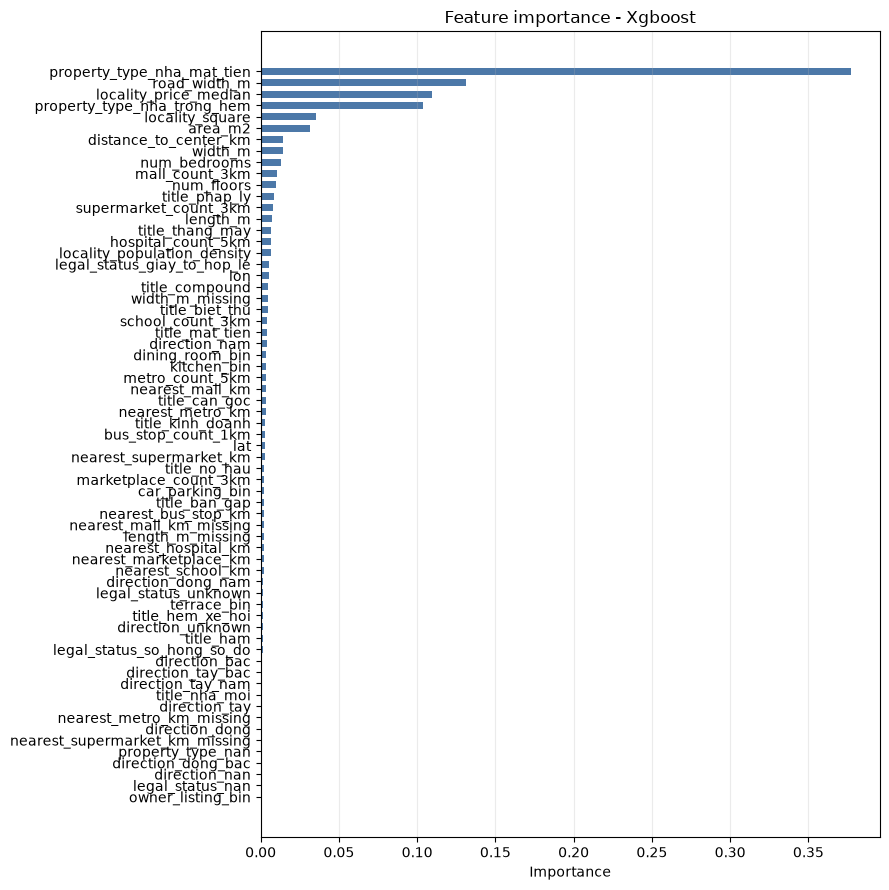

In [29]:
importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(importance.index, importance.values, height=0.62, color='#4C78A8')
ax.set_title(f"Feature importance - {best_name.replace('_', ' ').title()}")
ax.set_xlabel('Importance')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

In [30]:
# Error by price segment — shows where the model is accurate and where it struggles
segments = [(0, 5), (5, 20), (20, 100)]
rows = []
for lo, hi in segments:
    mask = (y_test > lo) & (y_test <= hi)
    seg_true, seg_pred = y_test[mask], y_best_pred[mask]
    rows.append({
        'segment': f'{lo}–{hi} tỷ',
        'listings': int(mask.sum()),
        'MAE': mean_absolute_error(seg_true, seg_pred),
        'MAE_%_of_median': mean_absolute_error(seg_true, seg_pred) / seg_true.median() * 100,
    })

pd.DataFrame(rows).set_index('segment').round(2)

,listings,MAE,MAE_%_of_median
segment,,,
0–5 tỷ,178,1.57,37.99
5–20 tỷ,869,1.73,18.76
20–100 tỷ,492,8.86,22.14


### 1.10 Lưu model

In [31]:
model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

model_path = model_dir / f"{best_name}.joblib"
joblib.dump(best_model, model_path)
print(f"✓ Saved model: {model_path}")

metadata = {
    'model_type': best_name,
    'features': FEATURE_COLS,
    'metrics': {
        'r2_score': float(best_r2),
        'rmse': float(np.sqrt(mean_squared_error(y_test, y_best_pred))),
        'mae': float(mean_absolute_error(y_test, y_best_pred)),
        'mape': float(mean_absolute_percentage_error(y_test, y_best_pred) * 100),
    },
    'train_size': len(X_train),
    'test_size': len(X_test),
    # Model was trained on log1p(price) — inference must apply expm1
    'target_transform': 'log1p',
    # Locality target-encoding learned on the train set — needed at inference time
    'locality_price_map': locality_price_map.to_dict(),
    'locality_price_global': locality_price_global,
}
meta_path = model_dir / f"{best_name}_meta.pkl"
with open(meta_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Saved metadata: {meta_path}")

✓ Saved model: saved_models\xgboost.joblib
✓ Saved metadata: saved_models\xgboost_meta.pkl


## Part 2 — Inference

Load the saved best model and predict prices for **all** listings (using the data prepared in Part 1).

### 2.1 Load model đã lưu

In [32]:
model_dir = Path('saved_models')
model_files = sorted(model_dir.glob('*.joblib'))
assert model_files, "No trained models found — run Part 1 first"

latest_model = model_files[-1]
model = joblib.load(latest_model)

with open(model_dir / f"{latest_model.stem}_meta.pkl", 'rb') as f:
    metadata = pickle.load(f)

print(f"✓ Loaded {metadata['model_type']}")
print(
    f"  R²: {metadata['metrics']['r2_score']:.4f} | "
    f"RMSE: {metadata['metrics']['rmse']:.4f} billion VND | "
    f"MAE: {metadata['metrics']['mae']:.4f} billion VND | "
    f"MAPE: {metadata['metrics'].get('mape', float('nan')):.2f}%"
)

✓ Loaded xgboost
  R²: 0.8539 | RMSE: 7.6818 billion VND | MAE: 3.9871 billion VND | MAPE: 31.54%


### 2.2 Dự đoán cho toàn bộ listings

In [33]:
features = metadata['features']

# Build the feature matrix the same way as in training (build_features from Part 1)
feats_all = build_features(df)

# Apply the locality target-encoding learned during training (saved in metadata)
feats_all['locality_price_median'] = (
    feats_all['locality']
    .map(metadata['locality_price_map'])
    .fillna(metadata['locality_price_global'])
)

X_all = feats_all.reindex(columns=features, fill_value=0)

pred = model.predict(X_all)
if metadata.get('target_transform') == 'log1p':
    pred = np.expm1(pred)  # model was trained on log-price → back to billion VND

# build_features drops some rows (outliers, missing density),
# so align predictions back onto df by index — dropped rows stay NaN
df['predicted_price_billion_vnd'] = pd.Series(pred, index=X_all.index)

n_pred = df['predicted_price_billion_vnd'].notna().sum()
print(f"✓ Predicted {n_pred} of {len(df)} listings ({len(df) - n_pred} rows dropped by build_features)")
print(f"Prediction range: {df['predicted_price_billion_vnd'].min():.2f} – {df['predicted_price_billion_vnd'].max():.2f} billion VND")

df[['area_m2', 'distance_to_center_km', 'price_billion_vnd', 'predicted_price_billion_vnd']].head(10)

  build_features: dropped 944 outlier rows (8636 → 7692)
✓ Predicted 7692 of 8643 listings (951 rows dropped by build_features)
Prediction range: 0.81 – 101.77 billion VND


,area_m2,distance_to_center_km,price_billion_vnd,predicted_price_billion_vnd
0,50,3.067975,8.90,7.286687
1,92,0.627704,110.00,NaN
2,36,2.555122,7.99,7.587132
3,44,11.026162,4.35,4.544339
4,165,3.689532,45.00,44.545345
5,90,7.489329,1.05,1.110222
6,55,9.748404,5.38,5.961980
7,50,4.112581,7.30,7.326726
8,85,15.261734,1.95,1.953501
9,286,5.161158,45.00,NaN


### 2.3 Đánh giá dự đoán

Prediction error on all listings (with known price):
  MAE:  1.4561 billion VND
  RMSE: 3.7259 billion VND
  Mean error: -0.2704 billion VND


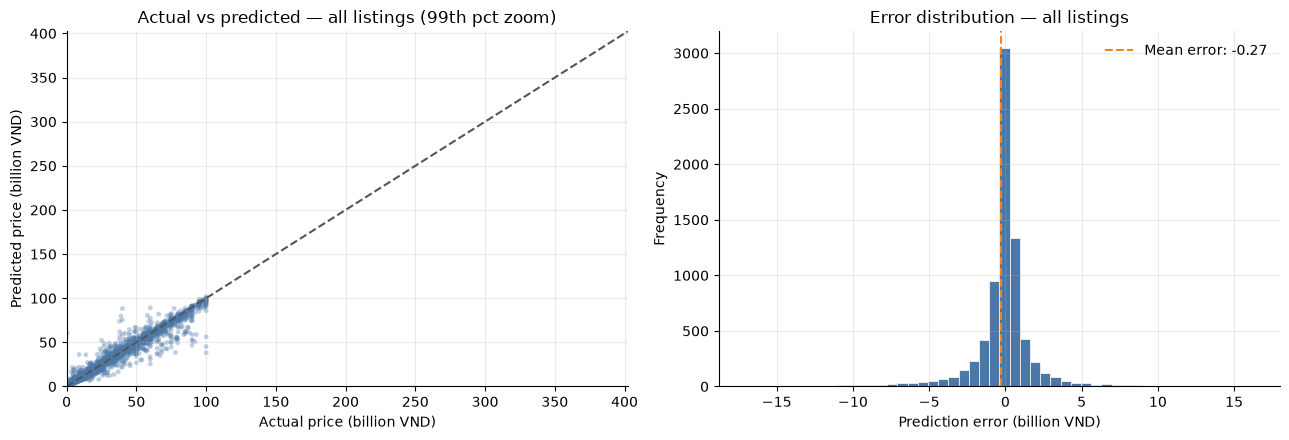

In [34]:
df['error_billion_vnd'] = df['predicted_price_billion_vnd'] - df['price_billion_vnd']

mae_all = df['error_billion_vnd'].abs().mean()
rmse_all = np.sqrt((df['error_billion_vnd'] ** 2).mean())
print("Prediction error on all listings (with known price):")
print(f"  MAE:  {mae_all:.4f} billion VND")
print(f"  RMSE: {rmse_all:.4f} billion VND")
print(f"  Mean error: {df['error_billion_vnd'].mean():.4f} billion VND")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['price_billion_vnd'], df['predicted_price_billion_vnd'],
                s=12, alpha=0.35, color='#4C78A8', edgecolors='none')
lims = [0, df['price_billion_vnd'].quantile(0.99)]
axes[0].plot(lims, lims, '--', color='#555555', lw=1.5)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual price (billion VND)')
axes[0].set_ylabel('Predicted price (billion VND)')
axes[0].set_title('Actual vs predicted — all listings (99th pct zoom)')
axes[0].grid(True, alpha=0.25)
axes[0].spines[['top', 'right']].set_visible(False)

err = df['error_billion_vnd'].dropna()
axes[1].hist(err[err.abs() < err.abs().quantile(0.99)], bins=50,
             color='#4C78A8', edgecolor='white', linewidth=0.5)
axes[1].axvline(err.mean(), color='#F58518', linestyle='--', lw=1.5,
                label=f'Mean error: {err.mean():.2f}')
axes[1].set_xlabel('Prediction error (billion VND)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error distribution — all listings')
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Lưu kết quả dự đoán

In [35]:
output_file = data_dir / 'predictions_latest.csv'
df.to_csv(output_file, index=False)

print(f"✓ Saved predictions: {output_file}")
print(f"  Records: {len(df)} | Size: {output_file.stat().st_size / 1024 / 1024:.2f} MB")
print("\n✅ Done!")

✓ Saved predictions: data\predictions_latest.csv
  Records: 8643 | Size: 6.54 MB

✅ Done!
